In [1]:
import os
import pickle
import random
import numpy as np
import scipy.signal
import scipy.fftpack
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from config import DUTCH_30_PATH
from run_pipeline import load_mfa_alignments, MFA_OUTPUT_PATH

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Using device: {DEVICE}")

# Determinism
SEED = 37
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch
  Using device: cuda


In [16]:
# ── 1. TORCH FIRST (before anything touches CUDA) ────────────────────────────
import torch
import torchaudio

# ── 2. TRANSFORMERS SECOND (before librosa loads via project imports) ─────────
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Wav2Vec2FeatureExtractor

# ── 3. STANDARD LIBRARIES ───────────────────────────────────────────────────────
import os
import gc
import copy
import glob
import json
import pickle
import tempfile
from datetime import datetime
from collections import Counter, defaultdict
from itertools import combinations

# ── 4. THIRD-PARTY (no CUDA) ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns
from pynwb import NWBHDF5IO
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cosine, euclidean
from scipy.signal import decimate

# ── 5. PROJECT IMPORTS ────────────────────────────────────────────────────────
from extract_features import extractHG, stackFeatures, downsampleLabels, extractMelSpecs
from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
from markov_phoneme_model import MarkovPhonemeModel
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from phoneme_detection_diagnostic import Dutch30PhonemeDetectionDiagnostic
from dataset_config import Dutch30Config
from experiment_logger import ExperimentLogger

# ── 6. WHISPERX  ──────────────────────────────────────────────────────────
import whisperx

In [26]:
# Patient list — every patient gets an input projection trained on their own
# data. Boundary detection is a per-patient task (deployed per-patient too),
# so we don't hold out whole patients. Instead, we use the patient's own
# training/test sentence split (see SENTENCE_TEST_FRACTION below).
ALL_PIDS = [f'P{i:02d}' for i in range(21, 31)]   # P21-P30 sentence patients
SENTENCE_TEST_FRACTION = 0.2          # within-patient sentence split for eval
SENTENCE_SPLIT_SEED    = 37           # for reproducible sentence splits

# Frame settings — match production extractHG defaults
SR             = 1024            # raw EEG sample rate
FRAME_HZ       = 200             # output framerate (5 ms / frame)
WINDOW_MS      = 15              # extractHG window length
FRAMESHIFT_MS  = 5               # 1000 / FRAME_HZ

# Boundary-label settings
LABEL_SIGMA_MS = 8               # Gaussian half-width on either side of boundary
LABEL_HARD_MS  = 20              # any frame within ±this gets label > 0.5

# Training settings
HIDDEN_DIM     = 128             # BiLSTM hidden size
N_LSTM_LAYERS  = 2
DROPOUT        = 0.3
N_EPOCHS       = 30
BATCH_SIZE     = 4               # batch of full-sentence sequences
LR             = 1e-3
WEIGHT_DECAY   = 1e-4
POS_WEIGHT     = 20.0             # BCE positive-class weight (~1/positive_rate)

# Boundary detection at inference
PEAK_HEIGHT    = 0.30            # min probability to count as a peak
PEAK_DISTANCE  = 8               # min frames between adjacent peaks (= 40 ms)
F1_TOLERANCE_MS = 20             # ±this = a true positive boundary detection

In [28]:
# Reuse the production envelope pipeline (pwr_lpf_10): squaring + Butterworth
# low-pass at 10 Hz + window-average + sqrt. This is the SAME envelope the
# rest of the production pipeline produces — we just stop before step5c's
# per-phoneme collapse, since the boundary detector needs frame-level data.
#
# Pipeline:
#   detrend → 70-170 Hz bandpass → 100/150 Hz notches (all 4th-order
#   Butterworth filtfilt) → x² → 10 Hz Butterworth low-pass filtfilt
#   → window-average → sqrt → (n_frames, n_channels)


def extract_frame_features(eeg, sr=SR, window_ms=WINDOW_MS,
                           frameshift_ms=FRAMESHIFT_MS, smoothing_hz=10.0):
    """High-gamma envelope features at 200 fps. (n_frames, n_channels).

    Identical to production extractHG (pwr_lpf_10) but returns the frame-level
    output (no per-phoneme collapse). Used as input to the boundary detector.
    """
    win   = window_ms / 1000.0
    shift = frameshift_ms / 1000.0
    data = scipy.signal.detrend(eeg, axis=0)

    sos_hg = scipy.signal.iirfilter(4, [70/(sr/2), 170/(sr/2)],
                                    btype='bandpass', output='sos')
    data = scipy.signal.sosfiltfilt(sos_hg, data, axis=0)
    for f_notch in (100.0, 150.0):
        sos_n = scipy.signal.iirfilter(4, [(f_notch-2)/(sr/2), (f_notch+2)/(sr/2)],
                                       btype='bandstop', output='sos')
        data = scipy.signal.sosfiltfilt(sos_n, data, axis=0)
    pwr = data ** 2
    sos_lp = scipy.signal.iirfilter(4, smoothing_hz/(sr/2),
                                    btype='lowpass', output='sos')
    smoothed = np.abs(scipy.signal.sosfiltfilt(sos_lp, pwr, axis=0))

    n_win = int(np.floor((data.shape[0] - win*sr) / (shift*sr)))
    feat = np.zeros((n_win, data.shape[1]))
    for w in range(n_win):
        s = int(np.floor(w * shift * sr))
        e = int(np.floor(s + win * sr))
        feat[w, :] = smoothed[s:e, :].mean(axis=0)
    return np.sqrt(feat)


In [29]:
# For each sentence in each patient:
#   - Extract per-frame features over the sentence's EEG segment
#   - Convert MFA's per-phoneme (start_s, end_s) into per-frame boundary labels
#   - Use a soft Gaussian centered at each boundary frame

def boundary_labels_from_mfa(phone_alignments, n_frames,
                              sr=SR, frame_hz=FRAME_HZ,
                              sigma_ms=LABEL_SIGMA_MS,
                              hard_ms=LABEL_HARD_MS):
    """Build a (n_frames,) array of soft boundary labels.

    Each phoneme's start_s and end_s contribute Gaussian-shaped labels at the
    corresponding frame indices.
    """
    sigma_frames = sigma_ms * frame_hz / 1000.0
    half_window  = max(1, int(np.ceil(3 * sigma_frames)))

    labels = np.zeros(n_frames, dtype=np.float32)
    boundary_times = []
    for ph in phone_alignments:
        boundary_times.append(ph['start_s'])
        boundary_times.append(ph['end_s'])
    # Deduplicate (consecutive phonemes share boundaries)
    boundary_times = sorted(set(round(t * frame_hz) / frame_hz
                                 for t in boundary_times))

    for t in boundary_times:
        center_frame = int(round(t * frame_hz))
        for off in range(-half_window, half_window + 1):
            f = center_frame + off
            if 0 <= f < n_frames:
                # Gaussian falloff
                w = np.exp(-(off ** 2) / (2 * sigma_frames ** 2))
                labels[f] = max(labels[f], w)

    return labels, boundary_times


def collect_sentences(pid, mfa_dir=MFA_OUTPUT_PATH, raw_dir=None):
    """For one patient, return list of dicts:
        {'frames': (n_frames, n_ch), 'labels': (n_frames,),
         'boundary_times': [...], 'sentence_idx': int}
    """
    if raw_dir is None:
        raw_dir = os.path.join(DUTCH_30_PATH, 'raw')

    # Load patient's full sEEG and audio + sentence segmentation
    eeg_path = os.path.join(raw_dir, f'{pid}_sEEG.npy')
    if not os.path.exists(eeg_path):
        print(f"  {pid}: no sEEG file, skipping")
        return []
    raw_eeg = np.load(eeg_path)

    # Load MFA alignments for this patient
    mfa = load_mfa_alignments(pid, mfa_dir)
    if not mfa:
        print(f"  {pid}: no MFA alignments, skipping")
        return []

    # Need sentence boundaries (start_s, end_s per sentence) — these come
    # from the pipeline's split_result. For a standalone script we need to
    # reconstruct them from the audio + transcript or load from a checkpoint.
    # ASSUMPTION: alignments are already aligned to the sentence's local time
    # (start_s = 0 at the beginning of each sentence).
    #
    # If the pipeline stores absolute times, you need to subtract the
    # sentence's start to get sentence-local times. Verify this matches your
    # data layout!

    # For a quick prototype, we can use ALL of the patient's EEG and concat
    # all phonemes into one long sequence — but timing alignment requires
    # knowing where each sentence starts in the full recording.
    #
    # Recommended: load from cached checkpoints that have per-sentence EEG
    # already segmented. This is what step5_accumulate / build_mfa_features
    # produces.

    # PLACEHOLDER: this function should be filled in based on YOUR data
    # layout. The expected output is a list of (sentence_eeg, mfa_phones)
    # tuples where sentence_eeg is the iEEG slice for that sentence.

    print(f"  {pid}: TODO — implement per-sentence EEG loading. Returning empty.")
    return []


In [30]:
# The cleanest way to reuse the existing alignment work: load the cached
# checkpoint that has per-sentence iEEG + MFA boundaries already.

def build_dataset_from_pipeline(pipeline, patient_ids):
    """Use the live pipeline to get per-sentence (frames, labels) tuples.

    Returns ALL sentences for the requested patients (no train/test split).
    Use split_dataset_by_sentence() afterwards to make the held-out split.

    Requires `pipeline.split_result['word_segments_dict'][pid]` to be populated.
    """
    dataset = []
    for pid in patient_ids:
        if pid not in pipeline.split_result.get('word_segments_dict', {}):
            print(f"  {pid}: not in split_result, skipping")
            continue

        wd = pipeline.split_result['word_segments_dict'][pid]
        eeg_segments = wd.get('eeg_segments', [])
        mfa = load_mfa_alignments(pid)

        for sent_idx, sent_eeg in enumerate(eeg_segments):
            if sent_idx not in mfa:
                continue
            phone_alignments = mfa[sent_idx]
            if not phone_alignments:
                continue

            try:
                frames = extract_frame_features(sent_eeg)
            except Exception as e:
                print(f"  {pid} sent {sent_idx}: extractHG failed: {e}")
                continue
            n_frames = frames.shape[0]
            labels, boundary_times = boundary_labels_from_mfa(
                phone_alignments, n_frames)

            dataset.append({
                'pid':            pid,
                'sentence_idx':   sent_idx,
                'frames':         frames,         # (n_frames, n_ch)
                'labels':         labels,         # (n_frames,) soft boundary
                'boundary_times': boundary_times, # list of times (s)
                'n_phonemes':     len(phone_alignments),
            })

    return dataset


def split_dataset_by_sentence(full_dataset,
                               test_fraction=SENTENCE_TEST_FRACTION,
                               seed=SENTENCE_SPLIT_SEED):
    """Per-patient deterministic sentence-level split.

    For each patient, randomly hold out `test_fraction` of sentences for
    evaluation. The split is done per-patient so every patient ends up in
    both train and test (avoids the "model has no projection for this PID"
    error and gives proper held-out sentences for F1 evaluation).

    Returns: (train_items, test_items)
    """
    rng = random.Random(seed)
    by_pid = defaultdict(list)
    for d in full_dataset:
        by_pid[d['pid']].append(d)
    train_items, test_items = [], []
    for pid, items in by_pid.items():
        order = list(range(len(items)))
        rng.shuffle(order)
        n_test = max(1, int(round(len(items) * test_fraction)))
        test_idxs  = set(order[:n_test])
        for i, item in enumerate(items):
            (test_items if i in test_idxs else train_items).append(item)
    return train_items, test_items


In [17]:
# create the pipeline
from run_pipeline import (
    # ── Configuration ─────────────────────────────────────────────────────
    DEFAULT_RUN_CONFIG,          # dict with all default hyperparameters

    # ── Pipeline paths (choose one) ───────────────────────────────────────
    # run_path_a,                # Path A: wav2vec/WhisperX boundary detection
    #                            #   - detects phoneme boundaries from audio in real time
    #                            #   - uses step4_custom_detector + step5_accumulate
    #                            #   - requires WhisperX model loaded (slow, ~1GB RAM)
    #                            #   - 3-level checkpoint system (step5 → frame → step3)
    run_path_b,                  # Path B: MFA pre-aligned TextGrids
                                 #   - reads phoneme timestamps from MFA TextGrid files
                                 #   - bypasses step4 + step5_accumulate entirely
                                 #   - requires mfa_output/ TextGrids to exist already
                                 #   - only needs step3 checkpoint (for train/test split)

    # ── Classification ────────────────────────────────────────────────────
    run_from_config,             # train + evaluate per-patient classifiers (uses run_config)
    # run_experiment,            # same but with explicit keyword args instead of dict

    # ── Analysis & diagnostics ────────────────────────────────────────────
    count,                       # print train/test sample counts
    analyze_consecutive_predictions,  # per-patient consecutive-correct runs + position stats
    # diagnose_mfa_loss,         # show where MFA phonemes are lost (min_samples, missing TG)
    # mfa_coverage_summary,      # per-patient MFA alignment coverage (sentences, phones)

    # ── MFA setup (one-time, already done for P21-P30) ────────────────────
    # export_sentences_for_mfa,  # export .wav + .lab per sentence for MFA input
    # clean_text_for_mfa,        # strip punctuation from transcripts
    # load_mfa_alignments,       # read TextGrid files into dict

    # ── Sweep ─────────────────────────────────────────────────────────────
    run_sweep,                 # grid search over stacking_order, step_size, frames, etc.

    # ── Helpers ───────────────────────────────────────────────────────────
    # attach_whisperx,           # load WhisperX model (only needed for Path A)
    # make_checkpoint_names,     # generate pickle filenames from run_config
)

run_config = dict(DEFAULT_RUN_CONFIG)
# Override if needed:
run_config['use_viterbi'] = True
# run_config['patient_range'] = (21, 30)
# run_config['stacking_order'] = 7
# run_config['stacking_step_size'] = 1
run_config['stacking_order']     = 20    # ±100 ms context at 5 ms shift
run_config['stacking_step_size'] = 1

# ---- Pipeline setup ----
extractor = Dutch30FeatureExtractor()
pipeline = Dutch30Pipeline(
    dutch30_extractor=extractor,
    debug_mode=False,
    feature_extraction_method=run_config['feature_extraction_method'],
    use_wav2vec=False,
    subtract_baseline=run_config['subtract_baseline'],
    use_rms_boundaries=False,
    use_multifeature=False,
)
pipeline.enable_debug()

# ── Run Path B (MFA) ─────────────────────────────────────────────────────────
cached_train, cached_test = run_path_b(pipeline, run_config)

# ── Classification ────────────────────────────────────────────────────────────
# name, params, results = run_from_config(pipeline, run_config)

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=100, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, groups=False

In [31]:

if 'pipeline' not in dir():
    print("  `pipeline` not found in scope.")
    print("    Build it first via your usual setup, e.g.:")
    print("      from run_pipeline import DEFAULT_RUN_CONFIG, run_path_b")
    print("      from dutch_30_pipeline import Dutch30Pipeline")
    print("      from dutch_30_feature_extractor import Dutch30FeatureExtractor")
    print("      extractor = Dutch30FeatureExtractor()")
    print("      pipeline = Dutch30Pipeline(extractor, ...)")
    print("      run_path_b(pipeline, dict(DEFAULT_RUN_CONFIG))")
else:
    print("\n  Building full per-sentence dataset for ALL patients...")
    full_dataset = build_dataset_from_pipeline(pipeline, ALL_PIDS)
    train_dataset, test_dataset = split_dataset_by_sentence(full_dataset)
    print(f"  total: {len(full_dataset)} sentences from "
          f"{len(set(d['pid'] for d in full_dataset))} patients")
    print(f"  train: {len(train_dataset)} sentences ({SENTENCE_TEST_FRACTION:.0%} held out)")
    print(f"  test:  {len(test_dataset)} sentences from "
          f"{len(set(d['pid'] for d in test_dataset))} patients")


  Building full per-sentence dataset for ALL patients...
  total: 953 sentences from 10 patients
  train: 762 sentences (20% held out)
  test:  191 sentences from 10 patients


In [32]:
# Channels vary in count and scale across patients. Normalize per patient
# using train-only statistics.

def fit_per_patient_stats(dataset):
    stats = {}
    by_pid = defaultdict(list)
    for d in dataset:
        by_pid[d['pid']].append(d['frames'])
    for pid, all_frames in by_pid.items():
        all_concat = np.concatenate(all_frames, axis=0)
        mu = all_concat.mean(axis=0, keepdims=True)
        sd = all_concat.std(axis=0, keepdims=True) + 1e-9
        stats[pid] = (mu, sd)
    return stats


def apply_stats(dataset, stats):
    for d in dataset:
        mu, sd = stats[d['pid']]
        d['frames'] = (d['frames'] - mu) / sd
    return dataset


if 'train_dataset' in dir() and train_dataset:
    print("\n  Computing and applying per-patient z-score normalization...")
    # Same patients in train and test (within-patient sentence split), so use
    # train statistics for BOTH — no leakage from test.
    train_stats = fit_per_patient_stats(train_dataset)
    train_dataset = apply_stats(train_dataset, train_stats)
    test_dataset  = apply_stats(test_dataset, train_stats)


  Computing and applying per-patient z-score normalization...


In [33]:
class SentenceDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        d = self.items[i]
        return (
            torch.from_numpy(d['frames'].astype(np.float32)),
            torch.from_numpy(d['labels'].astype(np.float32)),
            d['pid'],
            d['sentence_idx'],
        )


def collate_padded(batch):
    """Pad variable-length sequences to the longest in batch."""
    max_len = max(item[0].shape[0] for item in batch)
    n_ch    = batch[0][0].shape[1]

    X = torch.zeros(len(batch), max_len, n_ch)
    Y = torch.zeros(len(batch), max_len)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    pids = []
    sent_idxs = []

    for i, (frames, labels, pid, sent_idx) in enumerate(batch):
        n = frames.shape[0]
        X[i, :n] = frames
        Y[i, :n] = labels
        mask[i, :n] = True
        pids.append(pid)
        sent_idxs.append(sent_idx)

    return X, Y, mask, pids, sent_idxs

In [34]:
# Per-patient input projection (handles variable n_channels) → BiLSTM →
# per-frame boundary probability.

class BoundaryDetector(nn.Module):
    def __init__(self, per_patient_n_ch, hidden_dim=HIDDEN_DIM,
                 n_layers=N_LSTM_LAYERS, dropout=DROPOUT,
                 proj_dim=64):
        super().__init__()
        # Per-patient input projection (variable channel counts → fixed dim)
        self.projections = nn.ModuleDict({
            pid: nn.Linear(n_ch, proj_dim)
            for pid, n_ch in per_patient_n_ch.items()
        })
        # Shared BiLSTM
        self.lstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),  # boundary logit per frame
        )

    def forward(self, X, pid_list, mask=None):
        """X: (B, T, n_ch) — assumes all items in batch from same patient.
        Currently we batch by patient externally to avoid mixed projections.
        """
        # Project (uses the projection of the FIRST pid in pid_list — caller
        # ensures all batch items share a pid)
        h = self.projections[pid_list[0]](X)
        h, _ = self.lstm(h)
        logits = self.head(h).squeeze(-1)  # (B, T)
        return logits

In [35]:
def train_boundary_detector(train_dataset, n_epochs=N_EPOCHS, lr=LR):
    # Per-patient input dim
    per_patient_n_ch = {}
    for d in train_dataset:
        per_patient_n_ch[d['pid']] = d['frames'].shape[1]

    model = BoundaryDetector(per_patient_n_ch).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                   weight_decay=WEIGHT_DECAY)

    # Split items by patient so batches contain only one patient's data
    by_pid = defaultdict(list)
    for d in train_dataset:
        by_pid[d['pid']].append(d)
    pids = list(by_pid.keys())

    pos_weight = torch.tensor([POS_WEIGHT], device=DEVICE)

    print(f"\n  Training boundary detector — {n_epochs} epochs")
    for epoch in range(n_epochs):
        model.train()
        random.shuffle(pids)
        total_loss = 0.0
        total_frames = 0

        for pid in pids:
            items = by_pid[pid]
            random.shuffle(items)
            # Process this patient's sentences in mini-batches
            for batch_start in range(0, len(items), BATCH_SIZE):
                batch_items = items[batch_start:batch_start + BATCH_SIZE]
                # Convert to tensors
                batch = [(torch.from_numpy(d['frames'].astype(np.float32)),
                          torch.from_numpy(d['labels'].astype(np.float32)),
                          d['pid'], d['sentence_idx'])
                         for d in batch_items]
                X, Y, mask, pid_list, _ = collate_padded(batch)
                X = X.to(DEVICE); Y = Y.to(DEVICE); mask = mask.to(DEVICE)

                optimizer.zero_grad()
                logits = model(X, pid_list, mask=mask)
                loss = F.binary_cross_entropy_with_logits(
                    logits, Y, pos_weight=pos_weight, reduction='none'
                )
                loss = (loss * mask.float()).sum() / mask.float().sum().clamp(min=1)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss += loss.item() * mask.float().sum().item()
                total_frames += mask.float().sum().item()

        avg_loss = total_loss / max(total_frames, 1)
        print(f"    epoch {epoch+1:2d}/{n_epochs}  avg loss = {avg_loss:.4f}")
    return model


if 'train_dataset' in dir() and train_dataset:
    model = train_boundary_detector(train_dataset)


  Training boundary detector — 30 epochs
    epoch  1/30  avg loss = 0.9145
    epoch  2/30  avg loss = 0.8277
    epoch  3/30  avg loss = 0.7861
    epoch  4/30  avg loss = 0.6744
    epoch  5/30  avg loss = 0.7766
    epoch  6/30  avg loss = 0.6082
    epoch  7/30  avg loss = 0.5349
    epoch  8/30  avg loss = 0.5501
    epoch  9/30  avg loss = 0.4789
    epoch 10/30  avg loss = 0.4457
    epoch 11/30  avg loss = 0.4298
    epoch 12/30  avg loss = 0.4134
    epoch 13/30  avg loss = 0.3479
    epoch 14/30  avg loss = 0.3898
    epoch 15/30  avg loss = 0.3350
    epoch 16/30  avg loss = 0.3261
    epoch 17/30  avg loss = 0.2987
    epoch 18/30  avg loss = 0.2745
    epoch 19/30  avg loss = 0.2797
    epoch 20/30  avg loss = 0.2547
    epoch 21/30  avg loss = 0.2796
    epoch 22/30  avg loss = 0.2492
    epoch 23/30  avg loss = 0.2191
    epoch 24/30  avg loss = 0.1985
    epoch 25/30  avg loss = 0.1978
    epoch 26/30  avg loss = 0.1864
    epoch 27/30  avg loss = 0.1851
    epoch 28/

In [36]:
def predict_boundaries(model, frames_np, pid,
                       peak_height=PEAK_HEIGHT,
                       peak_distance=PEAK_DISTANCE):
    """Return list of frame-indexed boundary predictions."""
    model.eval()
    with torch.no_grad():
        X = torch.from_numpy(frames_np.astype(np.float32)).unsqueeze(0).to(DEVICE)
        logits = model(X, [pid])
        probs = torch.sigmoid(logits)[0].cpu().numpy()
    peaks, _ = scipy.signal.find_peaks(probs,
                                        height=peak_height,
                                        distance=peak_distance)
    return peaks, probs

In [37]:
def evaluate_f1(model, test_dataset,
                tolerance_ms=F1_TOLERANCE_MS):
    """Compute precision/recall/F1 of detected boundaries vs MFA boundaries."""
    tol_frames = int(tolerance_ms * FRAME_HZ / 1000)

    per_patient = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for d in test_dataset:
        peaks, _ = predict_boundaries(model, d['frames'], d['pid'])
        true_frames = sorted(set(int(round(t * FRAME_HZ))
                                  for t in d['boundary_times']))
        # Greedy matching with tolerance
        used_pred = [False] * len(peaks)
        used_true = [False] * len(true_frames)
        for ti, t in enumerate(true_frames):
            best_match = -1
            best_dist = tol_frames + 1
            for pi, p in enumerate(peaks):
                if used_pred[pi]:
                    continue
                dist = abs(p - t)
                if dist <= tol_frames and dist < best_dist:
                    best_match = pi
                    best_dist = dist
            if best_match >= 0:
                used_pred[best_match] = True
                used_true[ti] = True

        tp = sum(used_pred)
        fp = len(peaks) - tp
        fn = len(true_frames) - sum(used_true)
        per_patient[d['pid']]['tp'] += tp
        per_patient[d['pid']]['fp'] += fp
        per_patient[d['pid']]['fn'] += fn

    print(f"\n  Boundary detection F1 (tolerance ±{tolerance_ms} ms):")
    print(f"  {'pid':<5} {'TP':>6} {'FP':>6} {'FN':>6} "
          f"{'precision':>10} {'recall':>9} {'F1':>7}")
    print("  " + "-" * 55)
    f1s = []
    for pid in sorted(per_patient):
        s = per_patient[pid]
        prec = s['tp'] / max(s['tp'] + s['fp'], 1)
        rec  = s['tp'] / max(s['tp'] + s['fn'], 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-9)
        f1s.append(f1)
        print(f"  {pid:<5} {s['tp']:>6} {s['fp']:>6} {s['fn']:>6} "
              f"{prec:>9.2%} {rec:>8.2%} {f1:>6.3f}")
    print(f"\n  Mean F1: {np.mean(f1s):.3f}")
    return per_patient


if 'model' in dir() and 'test_dataset' in dir() and test_dataset:
    f1_results = evaluate_f1(model, test_dataset)


  Boundary detection F1 (tolerance ±20 ms):
  pid       TP     FP     FN  precision    recall      F1
  -------------------------------------------------------
  P21        1      9    579    10.00%    0.17%  0.003
  P22        3      7    629    30.00%    0.47%  0.009
  P23        5     29    628    14.71%    0.79%  0.015
  P24        1     12    626     7.69%    0.16%  0.003
  P25        3      7    702    30.00%    0.43%  0.008
  P26        0      0    487     0.00%    0.00%  0.000
  P27        0      2    593     0.00%    0.00%  0.000
  P28        0      2    595     0.00%    0.00%  0.000
  P29        0      5    752     0.00%    0.00%  0.000
  P30        0      1    587     0.00%    0.00%  0.000

  Mean F1: 0.004



  ════════════════════════════════════════════════════════════════
  ▶ Variant: 'baseline'  override={}
  ════════════════════════════════════════════════════════════════
      epoch 10/40  loss=2.0633
      epoch 20/40  loss=0.8982
      epoch 30/40  loss=0.4935
      epoch 40/40  loss=0.2692
    trained in 142 s
    BEST: F1=0.029  (prec=30.65%, rec=1.53%)  @ peak_height=0.05, peak_distance=4, tol=40ms

  ════════════════════════════════════════════════════════════════
  ▶ Variant: 'pos_weight=10'  override={'POS_WEIGHT': 10.0}
  ════════════════════════════════════════════════════════════════
      epoch 10/40  loss=0.5401
      epoch 20/40  loss=0.4092
      epoch 30/40  loss=0.2971
      epoch 40/40  loss=0.1822
    trained in 147 s
    BEST: F1=0.017  (prec=26.63%, rec=0.86%)  @ peak_height=0.05, peak_distance=6, tol=40ms

  ════════════════════════════════════════════════════════════════
  ▶ Variant: 'pos_weight=30'  override={'POS_WEIGHT': 30.0}
  ═════════════════════════════

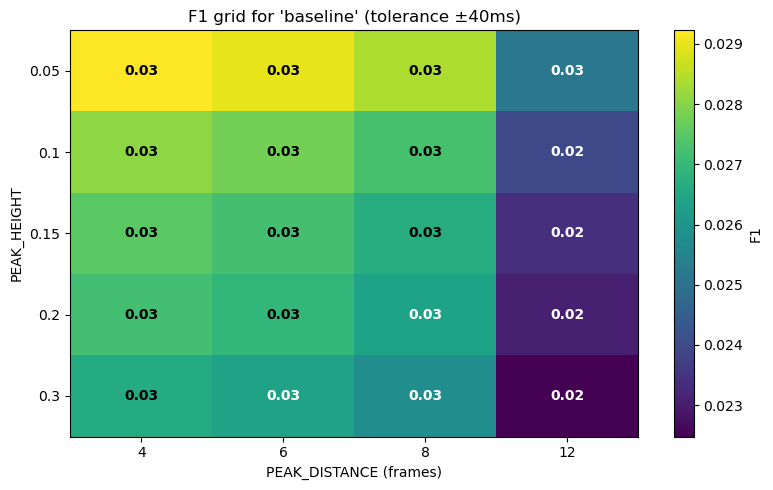


  Saved sweep results to boundary_sweep_20260502_1755.pkl


In [39]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL — Hyperparameter sweep for boundary detector
# ═══════════════════════════════════════════════════════════════════════════════
# Two-stage sweep:
#   1. Train each TRAINING variant (requires retraining each time, ~10-15 min)
#   2. For each trained model, evaluate at multiple PEAK_HEIGHT/DISTANCE/TOL
#      values (instant — no retraining)
#
# The training-time params are most impactful (POS_WEIGHT, N_EPOCHS, HIDDEN_DIM).
# Inference-time tuning gives a "best-case" F1 per trained model — pick the
# combo that maximises it.

import copy
import time
from datetime import datetime

# ── Base config (the current "best guess") ──────────────────────────────────
BASE = dict(
    POS_WEIGHT     = 20.0,
    HIDDEN_DIM     = 192,
    N_LSTM_LAYERS  = 2,
    DROPOUT        = 0.2,
    N_EPOCHS       = 40,
    LR             = 1e-3,
    WEIGHT_DECAY   = 1e-4,
    BATCH_SIZE     = 4,
)

# ── Training-time variants — each needs a full retrain ─────────────────────
TRAINING_SWEEP = [
    # name,               override dict
    ('baseline',          {}),
    ('pos_weight=10',     dict(POS_WEIGHT=10.0)),
    ('pos_weight=30',     dict(POS_WEIGHT=30.0)),
    ('pos_weight=50',     dict(POS_WEIGHT=50.0)),
    ('hidden=128',        dict(HIDDEN_DIM=128)),
    ('hidden=256',        dict(HIDDEN_DIM=256)),
    ('layers=1',          dict(N_LSTM_LAYERS=1)),
    ('layers=3',          dict(N_LSTM_LAYERS=3, DROPOUT=0.3)),  # more layers → more dropout
    ('epochs=80',         dict(N_EPOCHS=80)),
    ('dropout=0.0',       dict(DROPOUT=0.0)),
    ('lr=2e-3',           dict(LR=2e-3)),
    ('lr=5e-4',           dict(LR=5e-4)),
]

# ── Inference-time grid — evaluated for FREE on each trained model ─────────
PEAK_HEIGHTS   = [0.05, 0.10, 0.15, 0.20, 0.30]
PEAK_DISTANCES = [4, 6, 8, 12]      # frames (1 frame = 5 ms)
F1_TOLERANCES  = [10, 20, 40]       # ms


# ═══════════════════════════════════════════════════════════════════════════════
# Helpers
# ═══════════════════════════════════════════════════════════════════════════════

def train_with_config(train_dataset, cfg):
    """Reproducible training given a config override.
    Reuses the existing BoundaryDetector + collate/dataset logic from CELLs 8-10.
    """
    # Reset seeds for reproducibility
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    per_patient_n_ch = {}
    for d in train_dataset:
        per_patient_n_ch[d['pid']] = d['frames'].shape[1]

    model = BoundaryDetector(
        per_patient_n_ch,
        hidden_dim   = cfg['HIDDEN_DIM'],
        n_layers     = cfg['N_LSTM_LAYERS'],
        dropout      = cfg['DROPOUT'],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=cfg['LR'],
                                   weight_decay=cfg['WEIGHT_DECAY'])

    by_pid = defaultdict(list)
    for d in train_dataset:
        by_pid[d['pid']].append(d)
    pids = list(by_pid.keys())

    pos_weight = torch.tensor([cfg['POS_WEIGHT']], device=DEVICE)
    bs = cfg['BATCH_SIZE']

    for epoch in range(cfg['N_EPOCHS']):
        model.train()
        random.shuffle(pids)
        total_loss = 0.0
        total_frames = 0
        for pid in pids:
            items = by_pid[pid]
            random.shuffle(items)
            for i in range(0, len(items), bs):
                batch_items = items[i:i + bs]
                batch = [(torch.from_numpy(d['frames'].astype(np.float32)),
                          torch.from_numpy(d['labels'].astype(np.float32)),
                          d['pid'], d['sentence_idx'])
                         for d in batch_items]
                X, Y, mask, pid_list, _ = collate_padded(batch)
                X, Y, mask = X.to(DEVICE), Y.to(DEVICE), mask.to(DEVICE)
                optimizer.zero_grad()
                logits = model(X, pid_list, mask=mask)
                loss = F.binary_cross_entropy_with_logits(
                    logits, Y, pos_weight=pos_weight, reduction='none')
                loss = (loss * mask.float()).sum() / mask.float().sum().clamp(min=1)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item() * mask.float().sum().item()
                total_frames += mask.float().sum().item()
        # Print every 10 epochs to keep output short
        if (epoch + 1) % 10 == 0 or epoch == cfg['N_EPOCHS'] - 1:
            print(f"      epoch {epoch+1}/{cfg['N_EPOCHS']}  loss={total_loss/max(total_frames,1):.4f}")
    return model


def evaluate_f1_at(model, test_dataset, peak_height, peak_distance, tol_ms):
    """Single F1 number across all test patients."""
    tol_frames = int(tol_ms * FRAME_HZ / 1000)
    tp_total = fp_total = fn_total = 0

    for d in test_dataset:
        peaks, _ = predict_boundaries(
            model, d['frames'], d['pid'],
            peak_height=peak_height, peak_distance=peak_distance,
        )
        true_frames = sorted(set(int(round(t * FRAME_HZ))
                                  for t in d['boundary_times']))
        used_pred = [False] * len(peaks)
        used_true = [False] * len(true_frames)
        for ti, t in enumerate(true_frames):
            best_pi, best_dist = -1, tol_frames + 1
            for pi, p in enumerate(peaks):
                if used_pred[pi]:
                    continue
                dist = abs(p - t)
                if dist <= tol_frames and dist < best_dist:
                    best_pi, best_dist = pi, dist
            if best_pi >= 0:
                used_pred[best_pi] = True
                used_true[ti] = True
        tp_total += sum(used_pred)
        fp_total += len(peaks) - sum(used_pred)
        fn_total += len(true_frames) - sum(used_true)

    prec = tp_total / max(tp_total + fp_total, 1)
    rec  = tp_total / max(tp_total + fn_total, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    return {'precision': prec, 'recall': rec, 'f1': f1,
            'tp': tp_total, 'fp': fp_total, 'fn': fn_total}


# ═══════════════════════════════════════════════════════════════════════════════
# Run training-time sweep
# ═══════════════════════════════════════════════════════════════════════════════

results = {}
total_start = time.time()

for variant_name, override in TRAINING_SWEEP:
    cfg = {**BASE, **override}
    print(f"\n  ════════════════════════════════════════════════════════════════")
    print(f"  ▶ Variant: '{variant_name}'  override={override}")
    print(f"  ════════════════════════════════════════════════════════════════")

    t0 = time.time()
    model = train_with_config(train_dataset, cfg)
    train_time = time.time() - t0
    print(f"    trained in {train_time:.0f} s")

    # Evaluate on the inference-time grid (instant per evaluation)
    inference_results = {}
    for ph in PEAK_HEIGHTS:
        for pd in PEAK_DISTANCES:
            for tol in F1_TOLERANCES:
                metrics = evaluate_f1_at(model, test_dataset,
                                          peak_height=ph,
                                          peak_distance=pd,
                                          tol_ms=tol)
                inference_results[(ph, pd, tol)] = metrics

    # Best F1 for this trained model
    best_key = max(inference_results, key=lambda k: inference_results[k]['f1'])
    best_metrics = inference_results[best_key]
    print(f"    BEST: F1={best_metrics['f1']:.3f}  "
          f"(prec={best_metrics['precision']:.2%}, rec={best_metrics['recall']:.2%})  "
          f"@ peak_height={best_key[0]}, peak_distance={best_key[1]}, tol={best_key[2]}ms")

    results[variant_name] = {
        'config':            cfg,
        'override':          override,
        'train_time_s':      train_time,
        'inference_results': inference_results,
        'best_key':          best_key,
        'best_metrics':      best_metrics,
    }

print(f"\n  ════════════════════════════════════════════════════════════════")
print(f"  Total sweep time: {(time.time() - total_start)/60:.1f} min")


# ═══════════════════════════════════════════════════════════════════════════════
# Sweep summary
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print(f"  Sweep summary (best F1 per training variant)")
print("=" * 80)
print(f"  {'variant':<22} {'best F1':>9} {'precision':>10} {'recall':>9} "
      f"{'@thresh':>9} {'@tol':>6} {'time':>7}")
print("-" * 80)
for variant_name, r in sorted(results.items(),
                               key=lambda kv: -kv[1]['best_metrics']['f1']):
    bm = r['best_metrics']
    print(f"  {variant_name:<22} {bm['f1']:>8.3f}  "
          f"{bm['precision']:>9.2%} {bm['recall']:>8.2%}  "
          f"{r['best_key'][0]:>8.2f}  {r['best_key'][2]:>4}ms  "
          f"{r['train_time_s']:>5.0f}s")
print("=" * 80)

best_variant = max(results, key=lambda v: results[v]['best_metrics']['f1'])
print(f"\n  ★ Best variant overall: '{best_variant}'  "
      f"F1={results[best_variant]['best_metrics']['f1']:.3f}")


# ═══════════════════════════════════════════════════════════════════════════════
# Heatmap of inference-time grid for the best variant
# ═══════════════════════════════════════════════════════════════════════════════

best_inf = results[best_variant]['inference_results']

# 2D heatmap: peak_height × peak_distance, at the best tolerance
best_tol = results[best_variant]['best_key'][2]
heatmap = np.zeros((len(PEAK_HEIGHTS), len(PEAK_DISTANCES)))
for i, ph in enumerate(PEAK_HEIGHTS):
    for j, pd in enumerate(PEAK_DISTANCES):
        heatmap[i, j] = best_inf[(ph, pd, best_tol)]['f1']

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(PEAK_DISTANCES)))
ax.set_xticklabels(PEAK_DISTANCES)
ax.set_yticks(range(len(PEAK_HEIGHTS)))
ax.set_yticklabels(PEAK_HEIGHTS)
ax.set_xlabel('PEAK_DISTANCE (frames)')
ax.set_ylabel('PEAK_HEIGHT')
ax.set_title(f"F1 grid for '{best_variant}' (tolerance ±{best_tol}ms)")
for i in range(len(PEAK_HEIGHTS)):
    for j in range(len(PEAK_DISTANCES)):
        v = heatmap[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v < heatmap.mean() else 'black',
                fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax, label='F1')
plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# Save results
# ═══════════════════════════════════════════════════════════════════════════════

out_path = f'boundary_sweep_{datetime.now().strftime("%Y%m%d_%H%M")}.pkl'
to_save = {v: {k: r[k] for k in ('config', 'override', 'train_time_s',
                                  'best_key', 'best_metrics')}
           for v, r in results.items()}
with open(out_path, 'wb') as f:
    pickle.dump(to_save, f)
print(f"\n  Saved sweep results to {out_path}")

  Probability statistics across all test frames:
    min:    0.0000
    max:    0.9918
    mean:   0.0282
    median: 0.0000
    p95:    0.0857
    p99:    0.8502
  Threshold currently: 0.3


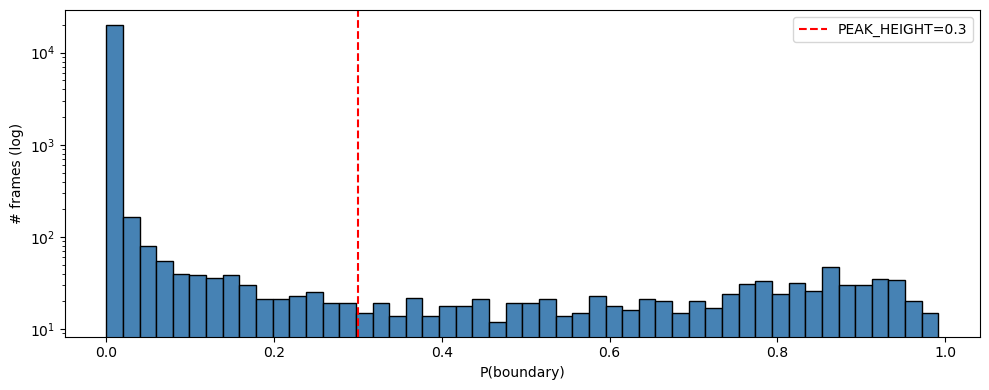

In [38]:
# Check what range of probabilities the model is outputting
all_probs = []
for d in test_dataset:
    _, probs = predict_boundaries(model, d['frames'], d['pid'])
    all_probs.append(probs)
all_probs_flat = np.concatenate(all_probs)

print(f"  Probability statistics across all test frames:")
print(f"    min:    {all_probs_flat.min():.4f}")
print(f"    max:    {all_probs_flat.max():.4f}")
print(f"    mean:   {all_probs_flat.mean():.4f}")
print(f"    median: {np.median(all_probs_flat):.4f}")
print(f"    p95:    {np.percentile(all_probs_flat, 95):.4f}")
print(f"    p99:    {np.percentile(all_probs_flat, 99):.4f}")
print(f"  Threshold currently: {PEAK_HEIGHT}")

# Histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_probs_flat, bins=50, color='steelblue', edgecolor='black')
ax.axvline(PEAK_HEIGHT, color='red', ls='--', label=f'PEAK_HEIGHT={PEAK_HEIGHT}')
ax.set_xlabel('P(boundary)')
ax.set_ylabel('# frames (log)')
ax.set_yscale('log')
ax.legend()
plt.tight_layout(); plt.show()

In [13]:
def plot_boundary_predictions(model, item, n_seconds=10):
    """Plot model output vs true boundaries for one sentence."""
    peaks, probs = predict_boundaries(model, item['frames'], item['pid'])
    n = min(int(n_seconds * FRAME_HZ), len(probs))
    t = np.arange(n) / FRAME_HZ

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

    # Top: model output + detected peaks
    axes[0].plot(t, probs[:n], lw=1.5, color='steelblue',
                 label='Detector output P(boundary)')
    peak_in_window = [p for p in peaks if p < n]
    axes[0].scatter([p/FRAME_HZ for p in peak_in_window],
                    [probs[p] for p in peak_in_window],
                    color='red', s=50, zorder=10,
                    label=f'Detected peaks ({len(peak_in_window)})')
    axes[0].axhline(PEAK_HEIGHT, color='gray', ls=':',
                    label=f'Threshold ({PEAK_HEIGHT})')
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].set_ylabel('Boundary probability')
    axes[0].legend(loc='upper right', fontsize=9)
    axes[0].grid(alpha=0.3)

    # Bottom: true MFA boundaries
    true_in_window = [t_b for t_b in item['boundary_times']
                      if t_b * FRAME_HZ < n]
    for tb in true_in_window:
        axes[1].axvline(tb, color='green', alpha=0.5, lw=1)
    axes[1].set_ylim(0, 1)
    axes[1].set_yticks([])
    axes[1].set_xlabel('Time (s)')
    axes[1].set_title(f'True MFA boundaries ({len(true_in_window)})',
                      color='green')

    plt.suptitle(f"{item['pid']} sentence {item['sentence_idx']}",
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()


if 'model' in dir() and 'test_dataset' in dir() and test_dataset:
    plot_boundary_predictions(model, test_dataset[0], n_seconds=8)

In [14]:
if 'model' in dir():
    out_path = f'boundary_detector_{datetime.now().strftime("%Y%m%d_%H%M")}.pt'
    torch.save({
        'model_state':       model.state_dict(),
        'per_patient_n_ch':  {pid: model.projections[pid].in_features
                               for pid in model.projections},
        'config': {
            'hidden_dim':     HIDDEN_DIM,
            'n_lstm_layers':  N_LSTM_LAYERS,
            'dropout':        DROPOUT,
            'frame_hz':       FRAME_HZ,
            'window_ms':      WINDOW_MS,
            'frameshift_ms':  FRAMESHIFT_MS,
            'label_sigma_ms': LABEL_SIGMA_MS,
            'pos_weight':     POS_WEIGHT,
        },
    }, out_path)
    print(f"\n  Saved trained detector to {out_path}")